In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [3]:
pd.set_option('display.max_columns', 50)
sns.set_style("whitegrid")

Load and prep data

In [4]:
df = pd.read_csv("merged_streaming_data.csv")
df.head()


,id_student,code_module,code_presentation,date,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity,id_assessment,is_banked,score,assessment_type,due_date,weight,module_presentation_length,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration
0,6516,AAA,2014J,-23.0,0,3,23,2,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
1,6516,AAA,2014J,-22.0,33,13,34,0,0,2,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
2,6516,AAA,2014J,-20.0,13,12,8,1,0,7,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
3,6516,AAA,2014J,-17.0,0,2,0,3,2,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
4,6516,AAA,2014J,-12.0,1,1,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN


In [25]:
print(df.columns)

vle_cols = df.columns[:24].tolist() + df.columns[30:].tolist()
activity_types = df.columns[4:24].tolist()
assessment_cols = df.columns[:4].tolist() + df.columns[24:].tolist()


Index(['id_student', 'code_module', 'code_presentation', 'date', 'forumng',
       'homepage', 'oucontent', 'subpage', 'url', 'resource', 'glossary',
       'dataplus', 'oucollaborate', 'quiz', 'ouelluminate', 'sharedsubpage',
       'questionnaire', 'page', 'externalquiz', 'ouwiki', 'dualpane',
       'repeatactivity', 'folder', 'htmlactivity', 'id_assessment',
       'is_banked', 'score', 'assessment_type', 'due_date', 'weight',
       'module_presentation_length', 'gender', 'region', 'highest_education',
       'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits',
       'disability', 'final_result', 'date_registration',
       'date_unregistration'],
      dtype='object')


In [6]:
df_vle = df[vle_cols]
df_vle.head()

,id_student,code_module,code_presentation,date,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity,module_presentation_length,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration
0,6516,AAA,2014J,-23.0,0,3,23,2,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
1,6516,AAA,2014J,-22.0,33,13,34,0,0,2,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
2,6516,AAA,2014J,-20.0,13,12,8,1,0,7,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
3,6516,AAA,2014J,-17.0,0,2,0,3,2,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
4,6516,AAA,2014J,-12.0,1,1,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN


In [7]:
dup_counts = df_vle.groupby(
    ["id_student", "code_module", "code_presentation"])["date"].apply(lambda x: x.value_counts().gt(1).sum())

print(dup_counts[dup_counts > 0])

id_student  code_module  code_presentation
8462        DDD          2014J                1
24186       GGG          2014B                2
26211       FFF          2014B                1
27189       FFF          2014B                2
27683       FFF          2014B                2
                                             ..
2697630     FFF          2014B                1
2697885     FFF          2014B                1
2697921     FFF          2013J                2
                         2014J                1
2698125     FFF          2013J                2
Name: date, Length: 5400, dtype: int64


In [8]:
# example, look at id_student==24186
df_vle[df_vle["id_student"]==24186]


,id_student,code_module,code_presentation,date,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity,module_presentation_length,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration
433,24186,GGG,2014B,-4.0,0,6,2,1,0,3,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,241,F,Yorkshire Region,Lower Than A Level,10-20,0-35,0,30,Y,Pass,-25.0,NaN
434,24186,GGG,2014B,6.0,0,1,0,0,0,1,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,241,F,Yorkshire Region,Lower Than A Level,10-20,0-35,0,30,Y,Pass,-25.0,NaN
435,24186,GGG,2014B,15.0,0,2,0,1,0,1,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,241,F,Yorkshire Region,Lower Than A Level,10-20,0-35,0,30,Y,Pass,-25.0,NaN
436,24186,GGG,2014B,29.0,0,1,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,241,F,Yorkshire Region,Lower Than A Level,10-20,0-35,0,30,Y,Pass,-25.0,NaN
437,24186,GGG,2014B,30.0,0,3,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,241,F,Yorkshire Region,Lower Than A Level,10-20,0-35,0,30,Y,Pass,-25.0,NaN
438,24186,GGG,2014B,34.0,0,1,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,241,F,Yorkshire Region,Lower Than A Level,10-20,0-35,0,30,Y,Pass,-25.0,NaN
439,24186,GGG,2014B,40.0,0,2,0,1,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,241,F,Yorkshire Region,Lower Than A Level,10-20,0-35,0,30,Y,Pass,-25.0,NaN
440,24186,GGG,2014B,55.0,0,1,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,241,F,Yorkshire Region,Lower Than A Level,10-20,0-35,0,30,Y,Pass,-25.0,NaN
441,24186,GGG,2014B,65.0,0,1,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,241,F,Yorkshire Region,Lower Than A Level,10-20,0-35,0,30,Y,Pass,-25.0,NaN
442,24186,GGG,2014B,67.0,3,3,0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,241,F,Yorkshire Region,Lower Than A Level,10-20,0-35,0,30,Y,Pass,-25.0,NaN


In [12]:
# Remove duplicate rows in df_vle (occurs when students submitted more than one assessment on a given day)
df_vle = df_vle.drop_duplicates()

# VLE interactions
summary = pd.DataFrame({
    'Zero Count': (df_vle == 0).sum(),
    'Null Count': (df_vle.shape[0]-df_vle.count()),
    'Non-Zero Count': (df_vle != 0).sum(),
    'Total Non-Null': df_vle.count()
})
summary['% Zero'] = (summary['Zero Count'] / summary['Total Non-Null'] * 100).round(2)
summary['% Non-Zero'] = (summary['Non-Zero Count'] / summary['Total Non-Null'] * 100).round(2)
print(summary)

                            Zero Count  Null Count  Non-Zero Count  \
id_student                           0           0         1862607   
code_module                          0           0         1862607   
code_presentation                    0           0         1862607   
date                              9465           0         1853142   
forumng                        1039712           0          822895   
homepage                        127381           0         1735226   
oucontent                      1033131           0          829476   
subpage                        1058030           0          804577   
url                            1548367           0          314240   
resource                       1462646           0          399961   
glossary                       1845349           0           17258   
dataplus                       1855789           0            6818   
oucollaborate                  1815273           0           47334   
quiz                

In [26]:
df_assessment = df[assessment_cols]
df_assessment.head()

,id_student,code_module,code_presentation,date,id_assessment,is_banked,score,assessment_type,due_date,weight,module_presentation_length,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration
0,6516,AAA,2014J,-23.0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
1,6516,AAA,2014J,-22.0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
2,6516,AAA,2014J,-20.0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
3,6516,AAA,2014J,-17.0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
4,6516,AAA,2014J,-12.0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN


In [27]:
# Remove rows in df_assessments with no assessment information (occurs when students had vle interactions but did not submit assessment)
df_assessment = df_assessment.dropna(subset=["id_assessment"])

# Assessment interactions
summary = pd.DataFrame({
    'Zero Count': (df_assessment == 0).sum(),
    'Null Count': (df_assessment.shape[0]-df_assessment.count()),
    'Non-Zero Count': (df_assessment != 0).sum(),
    'Total Non-Null': df_assessment.count()
})
summary['% Zero'] = (summary['Zero Count'] / summary['Total Non-Null'] * 100).round(2)
summary['% Non-Zero'] = (summary['Non-Zero Count'] / summary['Total Non-Null'] * 100).round(2)
print(summary)

                            Zero Count  Null Count  Non-Zero Count  \
id_student                           0           0          173912   
code_module                          0           0          173912   
code_presentation                    0           0          173912   
date                                61           0          173851   
id_assessment                        0           0          173912   
is_banked                       172003           0            1909   
score                              329         173          173583   
assessment_type                      0           0          173912   
due_date                             0        2865          173912   
weight                           46987           0          126925   
module_presentation_length           0           0          173912   
gender                               0           0          173912   
region                               0           0          173912   
highest_education   

In [28]:
df_assessment.head()

,id_student,code_module,code_presentation,date,id_assessment,is_banked,score,assessment_type,due_date,weight,module_presentation_length,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration
21,6516,AAA,2014J,17.0,1758.0,0.0,60.0,TMA,19.0,10.0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
40,6516,AAA,2014J,51.0,1759.0,0.0,48.0,TMA,54.0,20.0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
73,6516,AAA,2014J,116.0,1760.0,0.0,63.0,TMA,117.0,20.0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
103,6516,AAA,2014J,164.0,1761.0,0.0,61.0,TMA,166.0,20.0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
136,6516,AAA,2014J,210.0,1762.0,0.0,77.0,TMA,215.0,30.0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN


Feature engineering

In [ ]:
# create relative_submission_date column that calculates difference between due_date and date 
# positive values: assignment was submitted before due_date
# negative values: assignment was submitted after due_date

df_assessment["relative_submission_date"] = df_assessment["due_date"] - df_assessment["date"]
df_assessment[["id_student","date","id_assessment","score","assessment_type","due_date","relative_submission_date"]].head()

,id_student,date,id_assessment,score,assessment_type,due_date,relative_submission_date
21,6516,17.0,1758.0,60.0,TMA,19.0,2.0
40,6516,51.0,1759.0,48.0,TMA,54.0,3.0
73,6516,116.0,1760.0,63.0,TMA,117.0,1.0
103,6516,164.0,1761.0,61.0,TMA,166.0,2.0
136,6516,210.0,1762.0,77.0,TMA,215.0,5.0


In [48]:
# How often do students submit exactly on the due_date (i.e., relative_submission_date=0)? 

print('Number of instances assessment is submitted on due date:' , (df_assessment["relative_submission_date"]==0).sum())
print('Percentage of instances assessment is submitted on due date:' ,((df_assessment["relative_submission_date"] == 0).mean()*100).round(1),'%')

Number of instances assessment is submitted on due date: 29469
Percentage of instances assessment is submitted on due date: 16.9 %


In [51]:
# create submission_type column that indicates whether submission was on time (early) or late

df_assessment["submission_type"] = np.where(df_assessment["relative_submission_date"] < 0, "Late", "Early")

In [52]:
df_assessment.head()

,id_student,code_module,code_presentation,date,id_assessment,is_banked,score,assessment_type,due_date,weight,module_presentation_length,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,relative_submission_date,submission_type
21,6516,AAA,2014J,17.0,1758.0,0.0,60.0,TMA,19.0,10.0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,2.0,Early
40,6516,AAA,2014J,51.0,1759.0,0.0,48.0,TMA,54.0,20.0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,3.0,Early
73,6516,AAA,2014J,116.0,1760.0,0.0,63.0,TMA,117.0,20.0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,1.0,Early
103,6516,AAA,2014J,164.0,1761.0,0.0,61.0,TMA,166.0,20.0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,2.0,Early
136,6516,AAA,2014J,210.0,1762.0,0.0,77.0,TMA,215.0,30.0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,5.0,Early


In [76]:
# Create relative due date column
df_assessment["due_date_prop"] = df_assessment["due_date"] / df_assessment["module_presentation_length"]

In [83]:
df_assessment_metadata = df_assessment[["code_module", "code_presentation", "assessment_type","id_assessment","due_date","weight","module_presentation_length"]].drop_duplicates()
df_assessment_metadata.head()

,code_module,code_presentation,assessment_type,id_assessment,due_date,weight,module_presentation_length
21,AAA,2014J,TMA,1758.0,19.0,10.0,269
40,AAA,2014J,TMA,1759.0,54.0,20.0,269
73,AAA,2014J,TMA,1760.0,117.0,20.0,269
103,AAA,2014J,TMA,1761.0,166.0,20.0,269
136,AAA,2014J,TMA,1762.0,215.0,30.0,269


EDA: How many assessments and when they happen

In [78]:
df_assessment_metadata["assessment_type"].value_counts()

assessment_type
TMA     106
CMA      76
Exam      6
Name: count, dtype: int64

In [79]:
assessment_count = df_assessment_metadata.groupby(
    ["code_module", "code_presentation", "assessment_type"]
)["id_assessment"].nunique().reset_index(name="unique_assessments")

assessment_count

# NB: Not all (code_module, code_presentation) combination has all assessment_types 
# Final exam (assessment_type = Exam) is only available in 6 of the (code_module, code_presentation) combinations

,code_module,code_presentation,assessment_type,unique_assessments
0,AAA,2013J,TMA,5
1,AAA,2014J,TMA,5
2,BBB,2013B,CMA,5
3,BBB,2013B,TMA,6
4,BBB,2013J,CMA,5
5,BBB,2013J,TMA,6
6,BBB,2014B,CMA,5
7,BBB,2014B,TMA,6
8,BBB,2014J,TMA,5
9,CCC,2014B,CMA,4


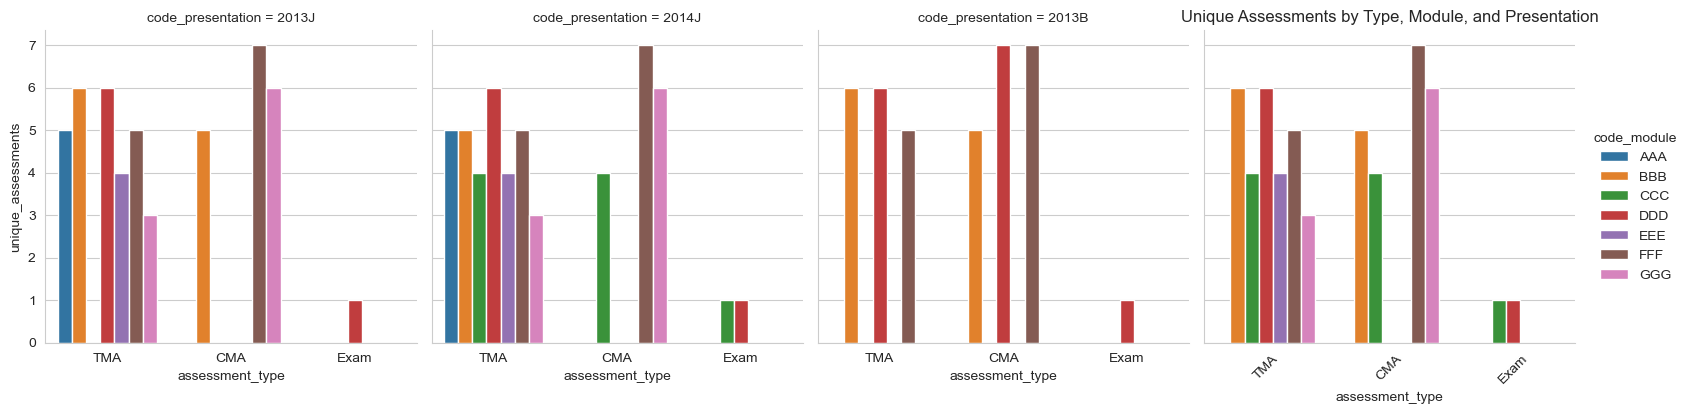

In [80]:
sns.catplot(
    data=assessment_count,
    x="assessment_type",
    y="unique_assessments",
    hue="code_module",
    col="code_presentation",  # facet by presentation
    kind="bar",
    height=4,
    aspect=1
)

plt.xticks(rotation=45)
plt.ylabel("Number of Unique Assessments")
plt.title("Unique Assessments by Type, Module, and Presentation")
plt.show()


In [81]:
df_assessment_metadata.groupby(
    ["code_module", "code_presentation", "assessment_type"]
)["due_date"].describe()

count        mean        std  \
code_module code_presentation assessment_type                                 
AAA         2013J             TMA                5.0  114.200000  79.904318   
            2014J             TMA                5.0  114.200000  79.904318   
BBB         2013B             CMA                5.0  122.600000  53.172361   
                              TMA                6.0  104.166667  64.827206   
            2013J             CMA                5.0  131.000000  59.808026   
                              TMA                6.0  111.166667  71.580491   
            2014B             CMA                5.0  118.400000  57.596007   
                              TMA                6.0   99.500000  68.549982   
            2014J             TMA                5.0  107.200000  73.182648   
CCC         2014B             CMA                4.0  107.250000  82.504040   
                              Exam               0.0         NaN        NaN   
                              TMA                4.0  121.250000  71.700186   
            2014J             CMA                4.0  110.750000  86.183428   
                              Exam               0.0         NaN        NaN   
                              TMA                4.0  126.500000  74.630199   
DDD         2013B             CMA                7.0  113.142857  66.200273   
                              Exam               1.0  240.000000        NaN   
                              TMA                6.0  104.333333  64.713729   
            2013J             Exam               1.0  261.000000        NaN   
                              TMA                6.0  110.166667  68.645223   
            2014B             Exam               1.0  241.000000        NaN   
                              TMA                6.0  104.333333  66.358622   
            2014J             Exam               0.0         NaN        NaN   
                              TMA                6.0   95.833333  67.056444   
EEE         2013J             TMA                4.0   96.000000  56.290911   
            2014B             TMA                4.0   92.500000  52.538874   
            2014J             TMA                4.0   99.500000  60.080502   
FFF         2013B             CMA                7.0  222.000000   0.000000   
                              TMA                5.0   90.400000  59.889899   
            2013J             CMA                7.0  236.000000   0.000000   
                              TMA                5.0   93.200000  62.138555   
            2014B             CMA                7.0  227.000000   0.000000   
                              TMA                5.0   92.600000  58.858304   
            2014J             CMA                7.0  241.000000   0.000000   
                              TMA                5.0  101.000000  69.296465   
GGG         2013J             CMA                6.0  229.000000   0.000000   
                              TMA                3.0  119.333333  56.145644   
            2014B             CMA                6.0  222.000000   0.000000   
                              TMA                3.0  114.666667  52.538874   
            2014J             CMA                6.0  229.000000   0.000000   
                              TMA                3.0  119.333333  56.145644   

                                                 min     25%    50%     75%  \
code_module code_presentation assessment_type                                 
AAA         2013J             TMA               19.0   54.00  117.0  166.00   
            2014J             TMA               19.0   54.00  117.0  166.00   
BBB         2013B             CMA               54.0   89.00  124.0  159.00   
                              TMA               19.0   57.50  106.5  150.25   
            2013J             CMA               54.0   96.00  131.0  166.00   
                              TMA               19.0   59.25  113.5  157.25   
            2014B

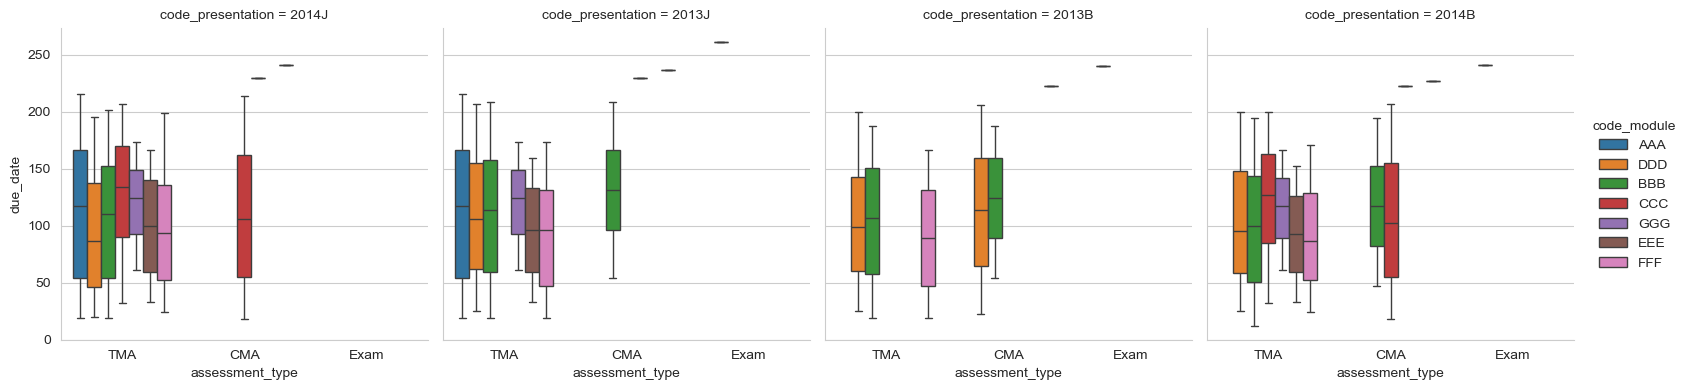

In [82]:
sns.catplot(
    data=df_assessment_metadata,
    x="assessment_type",
    y="due_date",
    hue="code_module",
    col="code_presentation",
    kind="box",
    height=4,
    aspect=1
)


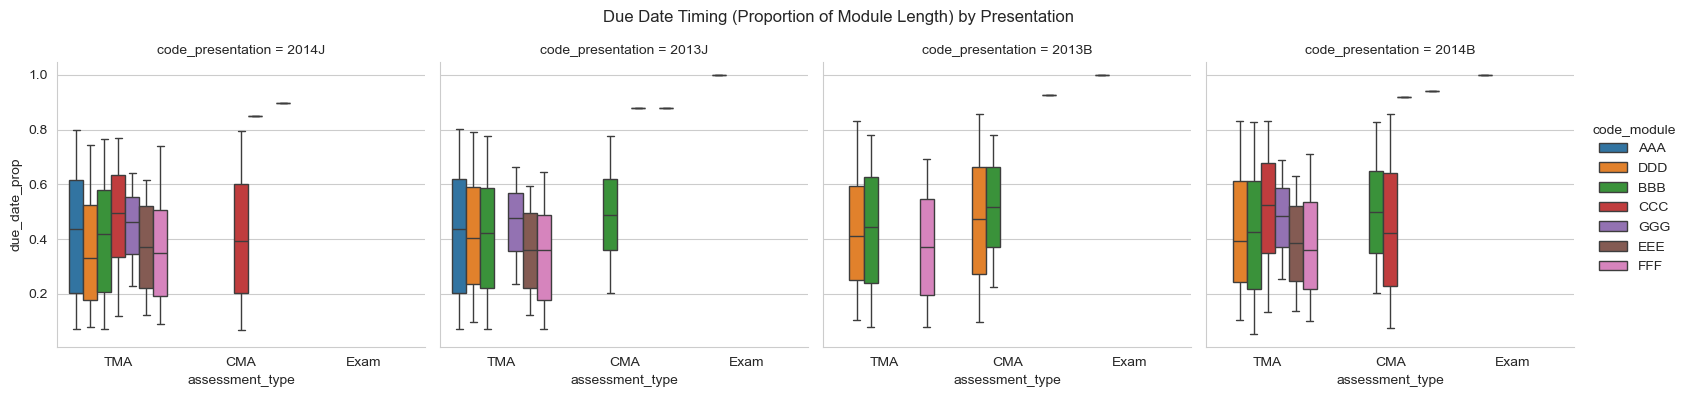

In [ ]:
sns.catplot(
    data=df_assessment_metadata,
    x="assessment_type",
    y="due_date_prop",
    hue="code_module",
    col="code_presentation",  # facet by presentation
    kind="box",
    height=4,
    aspect=1
)

plt.subplots_adjust(top=0.85)  # Adjust space for title
plt.suptitle("Due Date Timing (Proportion of Module Length) by Presentation")
plt.show()


EDA: 

In [95]:
submission_type_counts = (
    df_assessment[df_assessment["assessment_type"] != "Exam"]
    .groupby(["code_module","code_presentation","id_student", "final_result", "submission_type"])
    .size()
    .unstack(fill_value=0)  # columns will be 'Early' and 'Late'
    .reset_index()
)
submission_type_counts["prop_early"] = submission_type_counts["Early"] / (submission_type_counts["Early"] + submission_type_counts["Late"])

submission_type_counts


submission_type,code_module,code_presentation,id_student,final_result,Early,Late,prop_early
0,AAA,2013J,11391,Pass,5,0,1.000000
1,AAA,2013J,28400,Pass,3,2,0.600000
2,AAA,2013J,31604,Pass,5,0,1.000000
3,AAA,2013J,32885,Pass,0,5,0.000000
4,AAA,2013J,38053,Pass,4,1,0.800000
...,...,...,...,...,...,...,...
25834,GGG,2014J,2620947,Distinction,8,1,0.888889
25835,GGG,2014J,2645731,Distinction,7,2,0.777778
25836,GGG,2014J,2648187,Pass,9,0,1.000000
25837,GGG,2014J,2679821,Withdrawn,2,0,1.000000


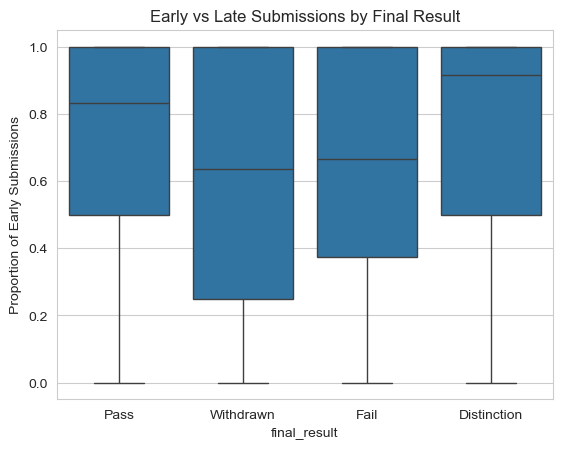

In [96]:

sns.boxplot(
    data=submission_type_counts,
    x="final_result",
    y="prop_early"
)

plt.ylabel("Proportion of Early Submissions")
plt.title("Early vs Late Submissions by Final Result")
plt.show()


In [97]:
submission_type_counts.groupby("final_result")[["Early", "Late", "prop_early"]].mean()


submission_type,Early,Late,prop_early
final_result,,,
Distinction,6.446429,1.969246,0.764396
Fail,2.984221,1.835096,0.636747
Pass,6.088547,2.217159,0.739507
Withdrawn,1.643725,1.146388,0.586462


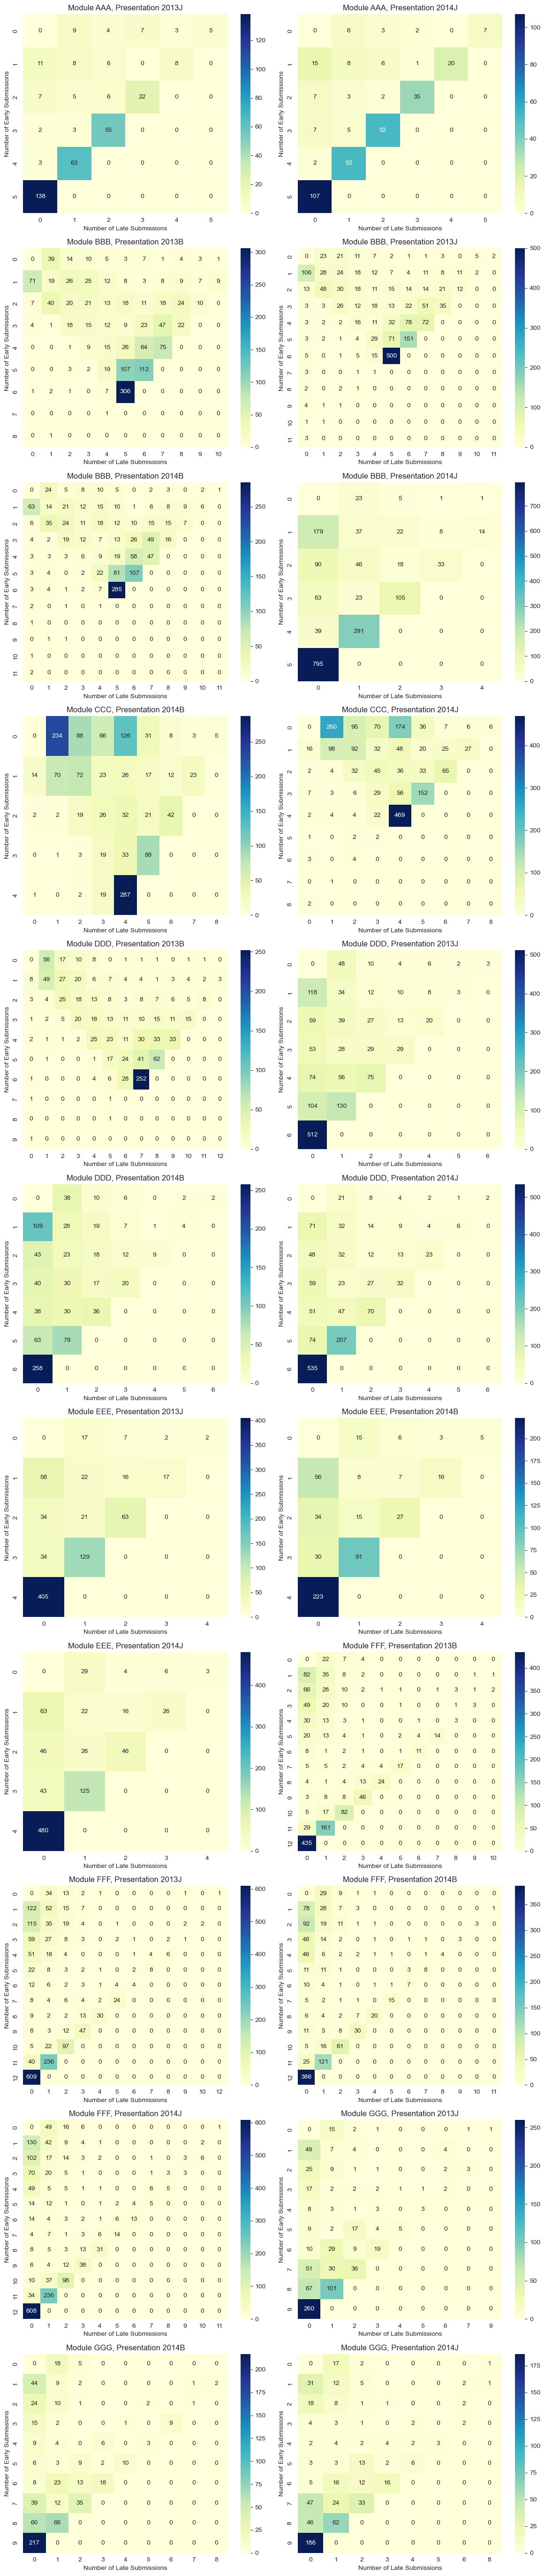

In [ ]:
# Identify unique module/presentation combinations
module_presentations = submission_type_counts[["code_module", "code_presentation"]].drop_duplicates()

# Set up subplot grid
n_plots = len(module_presentations)
n_cols = 2  # adjust number of columns
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 5))
axes = axes.flatten()  # flatten in case of multiple rows

# Loop through each module/presentation
for i, (_, row) in enumerate(module_presentations.iterrows()):
    module = row["code_module"]
    presentation = row["code_presentation"]
    
    subset = submission_type_counts[
        (submission_type_counts["code_module"] == module) &
        (submission_type_counts["code_presentation"] == presentation)
    ]
    
    # Pivot for heatmap
    heatmap_data = subset.pivot_table(
        index="Early",
        columns="Late",
        values="id_student",
        aggfunc="count",
        fill_value=0
    )
    
    # Plot heatmap in the corresponding subplot
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt="d",
        cmap="YlGnBu",
        ax=axes[i]
    )
    axes[i].set_title(f"Module {module}, Presentation {presentation}")
    axes[i].set_ylabel("Number of Early Submissions")
    axes[i].set_xlabel("Number of Late Submissions")

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()